In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
sns.set()
import os

In [2]:
healthy_dirs = ["GSM" + str(3587996 + i) for i in range(0, 8)]
others_dirs = ["GSM" + str(3588004 + i) for i in range(0, 2)]

samples = {"healthy": {}, "unhealthy": {}, "others": {}}

for sample_dir in os.listdir("../datasets/GSE116256"):
    if sample_dir.endswith(".csv"):
        continue
    for file in os.listdir("../datasets/GSE116256/" + sample_dir):
        # print(file)
        sample = file.split(".")[0].split("_")[-1].split("-")

        sample_type = (
            "healthy"
            if sample_dir in healthy_dirs
            else "others"
            if sample_dir in others_dirs
            else "unhealthy"
        )

        sample_code = sample[1] if len(sample) > 1 else "/"

        sample_file = (
            "dem"
            if file.endswith(".dem.txt")
            else "nanopore"
            if file.endswith(".nanopore.txt")
            else "anno"
        )

        if sample[0] not in samples[sample_type].keys():
            samples[sample_type][sample[0]] = {
                sample_code: {
                    sample_file: pd.read_csv(
                        "../datasets/GSE116256/" + sample_dir + "/" + file,
                        sep="\t",
                        index_col=0,
                        header=0,
                    )
                }
            }

        elif sample_code not in samples[sample_type][sample[0]].keys():
            samples[sample_type][sample[0]][sample_code] = {
                sample_file: pd.read_csv(
                    "../datasets/GSE116256/" + sample_dir + "/" + file,
                    sep="\t",
                    index_col=0,
                    header=0,
                )
            }

        else:
            samples[sample_type][sample[0]][sample_code][sample_file] = pd.read_csv(
                "../datasets/GSE116256/" + sample_dir + "/" + file,
                sep="\t",
                index_col=0,
                header=0,
            )
            
clear_output()

In [3]:
all_unhealthies = None

for sample in samples:
    if sample == "unhealthy":
        for sample_case in samples[sample]:
            for sample_code in samples[sample][sample_case]:
                for sample_file in samples[sample][sample_case][sample_code]:
                    if sample_file == 'dem':
                        print(sample, sample_case, sample_code, sample_file)
                        if all_unhealthies is None:
                            all_unhealthies = samples[sample][sample_case][sample_code][sample_file]
                        else:
                            all_unhealthies = pd.concat([all_unhealthies, samples[sample][sample_case][sample_code][sample_file]], axis=1)
                        print('added!')
clear_output()

In [4]:
all_unhealthies_anno = None

for sample in samples:
    if sample == "unhealthy":
        for sample_case in samples[sample]:
            for sample_code in samples[sample][sample_case]:
                for sample_file in samples[sample][sample_case][sample_code]:
                    if sample_file == 'anno':
                        print(sample, sample_case, sample_code, sample_file)
                        if all_unhealthies_anno is None:
                            all_unhealthies_anno = samples[sample][sample_case][sample_code][sample_file]
                        else:
                            all_unhealthies_anno = pd.concat([all_unhealthies_anno, samples[sample][sample_case][sample_code][sample_file]], axis=0)
                        print('added!')
clear_output()                

In [5]:
all_healthies = None

for sample in samples:
    if sample == "healthy":
        for sample_case in samples[sample]:
            for sample_code in samples[sample][sample_case]:
                for sample_file in samples[sample][sample_case][sample_code]:
                    if sample_file == 'dem':
                        print(sample, sample_case, sample_code, sample_file)
                        if sample_code != '34p38n':
                            if all_healthies is None:
                                all_healthies = samples[sample][sample_case][sample_code][sample_file]
                            else:
                                all_healthies = pd.concat([all_healthies, samples[sample][sample_case][sample_code][sample_file]], axis=1)
                        else:
                            if all_healthies is None:
                                # all_healthies = samples[sample][sample_case][sample_code][sample_file].sample(n=783, axis=1)
                                all_healthies = samples[sample][sample_case][sample_code][sample_file]
                            else:
                                # all_healthies = pd.concat([all_healthies, samples[sample][sample_case][sample_code][sample_file].sample(n=783, axis=1)], axis=1)
                                all_healthies = pd.concat([all_healthies, samples[sample][sample_case][sample_code][sample_file]], axis=1)
                        print('added!')   
clear_output()            

In [6]:
all_healthies_anno = None

for sample in samples:
    if sample == "healthy":
        for sample_case in samples[sample]:
            for sample_code in samples[sample][sample_case]:
                for sample_file in samples[sample][sample_case][sample_code]:
                    if sample_file == 'anno':
                        print(sample, sample_case, sample_code, sample_file)
                        if sample_code != '34p38n':
                            if all_healthies_anno is None:
                                all_healthies_anno = samples[sample][sample_case][sample_code][sample_file]
                            else:
                                all_healthies_anno = pd.concat([all_healthies_anno, samples[sample][sample_case][sample_code][sample_file]], axis=0)
                        else:
                            if all_healthies_anno is None:
                                # all_healthies_anno = samples[sample][sample_case][sample_code][sample_file].sample(n=783, axis=1)
                                all_healthies_anno = samples[sample][sample_case][sample_code][sample_file]
                            else:
                                # all_healthies_anno = pd.concat([all_healthies_anno, samples[sample][sample_case][sample_code][sample_file].sample(n=783, axis=1)], axis=1)
                                all_healthies_anno = pd.concat([all_healthies_anno, samples[sample][sample_case][sample_code][sample_file]], axis=0)
                        print('added!')        
clear_output()       

In [7]:
variably_expressed_genes = pd.read_csv('./variably_expressed_genes.csv', index_col=0).index

In [8]:
target_cells = ['HSC', 'Prog', 'GMP', 'ProMono', 'Mono', 'cDC']
target_cell = 'HSC'

##### Impatients (Normal Cells)

In [232]:
all_healthies_anno['CellType'].unique()

array(['cDC', 'GMP', 'T', 'ProB', 'Mono', 'Prog', 'CTL', 'HSC', 'lateEry',
       'ProMono', 'pDC', 'Plasma', 'earlyEry', 'B', 'NK', nan],
      dtype=object)

In [233]:
impatient_normal_cells = all_healthies[all_healthies_anno.query(f"CellType == '{target_cell}'").index]
impatient_normal_cells

,BM1_AGGCGGGCGTGN,BM1_ATAACATTTCAC,BM2_CGGCCCCGTCCA,BM2_CGGTGAGCATCC,BM2_GTAGCTGATGCG,BM2_TATGCCTAGCGN,BM2_CCCTAGTCCATN,BM3_ATGGTTAACAGT,BM3_CCGCGTGAACGT,BM3_CTAGTCAAGCGG,...,BM5-34p38n_TGAGGTACTCGA,BM5-34p38n_ACAACTAGGTGC,BM5-34p38n_AGGAGCGTACGG,BM5-34p38n_CTCAAAAGATCC,BM5-34p38n_GTGGGTAACGAC,BM5-34p38n_CCGGACTTCGCA,BM5-34p38n_CGACTTCCGTTA,BM5-34p38n_AGTGCTCTGAGT,BM5-34p38n_TTGTATCCTCCC,BM5-34p38n_AGTGAAAGGACA
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
A1BG-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYG11B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYX,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0


##### Patients (Normal Cells, Cancerous Cells)

In [234]:
all_unhealthies_anno['CellType'].unique()

array(['GMP', 'GMP-like', 'Prog-like', 'ProMono-like', 'HSC-like',
       'cDC-like', 'Mono-like', 'Mono', 'Prog', 'cDC', 'HSC', 'ProMono',
       'earlyEry', 'CTL', 'T', 'Plasma', 'ProB', 'NK', 'B', 'lateEry',
       'pDC'], dtype=object)

In [235]:
patient_normal_cells = all_unhealthies[all_unhealthies_anno.query(f"CellType == '{target_cell}'").index]
patient_normal_cells

,AML1012-D0_ACGTCGGTAGCN,AML1012-D0_CAGCCGTATCAN,AML1012-D0_CCCACTGATTTC,AML1012-D0_CGACTGAAATCT,AML1012-D0_CGAGATACTCTA,AML1012-D0_CTCTTGAAAAAC,AML1012-D0_CTTTATCGAAAC,AML1012-D0_GAGTTACGTCCN,AML1012-D0_GTAACACCAGAN,AML1012-D0_GTTGACGCGTGC,...,AML997-D0_CGATGTGTCTTG,AML997-D0_GAATTGAAGTTC,AML997-D0_GCTCTGCGGAGT,AML997-D0_TGTCGTGCGAGC,AML997-D0_TAGACACGTCGG,AML997-D0_AGTCGCTGCGAG,AML997-D0_CGGTCGACGTCA,AML997-D0_ATCGATGTCACC,AML997-D35_TTTTTGCGACAT,AML997-D35_TTACTGCACGCT
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1BG-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
A2M-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYG11B,0,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYX,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [236]:
patient_cancerous_cells = all_unhealthies[all_unhealthies_anno.query(f"CellType == '{target_cell}-like'").index]
patient_cancerous_cells

,AML1012-D0_AAACTTGCCCGT,AML1012-D0_AAGATAGATGAN,AML1012-D0_ACATTGGCCATN,AML1012-D0_ACTATCGGGTAC,AML1012-D0_AGGCGTCTTCTN,AML1012-D0_AGGGTTTCCTTN,AML1012-D0_AGGTGATAGATN,AML1012-D0_ATCACTGATTCA,AML1012-D0_ATGGGTCTAAAG,AML1012-D0_ATTTTTTAGTCN,...,AML921A-D0_TTGGGCTTGCCC,AML921A-D0_TTTAATCAATCA,AML921A-D0_TTTAATGCAATC,AML921A-D0_TTTCAAGAAACG,AML921A-D0_TTTCAGGCAGAA,AML921A-D0_TTTCGGACATCT,AML921A-D0_TTTCGGTTGATT,AML921A-D0_TTTCGTGCTTGA,AML921A-D0_TTTGACAACGAT,AML921A-D0_TTTTCTCCTGAC
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1BG-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M-AS1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYG11B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYX,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1


##### Differential Expression

In [237]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [238]:
def prepare_data_for_DeseqDataSet(positive_group, negative_group, condition_column="condition"):
    positive_samples = positive_group.T.copy()
    positive_metadata = pd.DataFrame(np.ones((positive_samples.shape[0], 1)), index=positive_samples.index, columns=[condition_column])

    negative_samples = negative_group.T.copy()
    negative_metadata = pd.DataFrame(np.zeros((negative_samples.shape[0], 1)), index=negative_samples.index, columns=[condition_column])

    count_data = pd.concat([negative_samples, positive_samples])
    metadata = pd.concat([negative_metadata, positive_metadata])
    
    return {"count_data": count_data, "metadata": metadata}

In [239]:
def exract_down_up_regulated_genes(results_df, only_variably_expressed_genes=True, p_value_threshold=0.05, log2FoldChange_threshold=0.05):
    results_df = results_df.copy()
    results_df['abs_stat'] = np.abs(results_df['stat'])
    results_df['abs_log2FoldChange'] = np.abs(results_df['log2FoldChange'])
    if only_variably_expressed_genes:
        d1 =  results_df.loc[variably_expressed_genes, :].sort_values(by=['abs_log2FoldChange', 'lfcSE', 'abs_stat', 'pvalue', 'padj'], ascending=[False, True, False, True, True])
    else:
        d1 =  results_df.sort_values(by=['abs_log2FoldChange', 'lfcSE', 'abs_stat', 'pvalue', 'padj'], ascending=[False, True, False, True, True])
    d1 = d1.query(f"pvalue < {p_value_threshold}")
    up_regulated = d1.query(f"log2FoldChange > {log2FoldChange_threshold}")
    down_regulated = d1.query(f"log2FoldChange < {-log2FoldChange_threshold}")
    return {"All": d1, "Up": up_regulated, "Down": down_regulated}

##### Patients:Normal Cells vs Patients:Cancerous Cells [Single Patient, Ignore Day]

In [240]:
patients = patient_cancerous_cells.columns.map(lambda x: x.split("-")[0]).unique().intersection(patient_normal_cells.columns.map(lambda x: x.split("-")[0]).unique())
patients

Index(['AML1012', 'AML210A', 'AML328', 'AML329', 'AML419A', 'AML420B',
       'AML475', 'AML556', 'AML707B', 'AML870', 'AML916', 'AML921A'],
      dtype='object')

In [241]:
results_patient = {}

for idx, patient in enumerate(patients):
    cancerous = patient_cancerous_cells.filter(regex=f"^{patient}")
    normal = patient_normal_cells.filter(regex=f"^{patient}")
    print(cancerous.shape, normal.shape)

    try:
        inference = DefaultInference()

        data = prepare_data_for_DeseqDataSet(cancerous, normal)

        dds = DeseqDataSet(
            counts=data["count_data"],
            metadata=data["metadata"],
            design_factors="condition",
            refit_cooks=True,
            inference=inference,
        )

        dds.deseq2()

        # print(dds)

        stat_res_p_p = DeseqStats(dds, inference=inference)

        stat_res_p_p.summary()

        results_patient[patient] = stat_res_p_p.results_df
    except KeyError as e:
        inference = DefaultInference()

        data = prepare_data_for_DeseqDataSet(cancerous, normal)

        dds = DeseqDataSet(
            counts=data["count_data"],
            metadata=data["metadata"],
            design_factors="condition",
            refit_cooks=False,
            inference=inference,
        )

        dds.deseq2()

        # print(dds)

        stat_res_p_p = DeseqStats(dds, inference=inference)

        stat_res_p_p.summary()

        results_patient[patient] = stat_res_p_p.results_df
        clear_output()

clear_output()

Patient AML1012 has 0 unique genes [p-value < 0.10 and log2FoldChange > 0.05]
Patient AML210A has 0 unique genes [p-value < 0.05 and log2FoldChange > 0.05]
Patient AML328 has 0 unique genes [p-value < 0.05 and log2FoldChange > 0.05]
Patient AML329 has 0 unique genes [p-value < 0.05 and log2FoldChange > 0.05]
Patient AML419A has 3 unique genes [p-value < 0.15 and log2FoldChange > 0.05]
Patient AML420B has 0 unique genes [p-value < 0.05 and log2FoldChange > 0.05]
Patient AML475 has 1 unique genes [p-value < 0.10 and log2FoldChange > 0.05]
Patient AML556 has 0 unique genes [p-value < 0.05 and log2FoldChange > 0.05]
Patient AML707B has 0 unique genes [p-value < 0.05 and log2FoldChange > 0.05]
Patient AML870 has 0 unique genes [p-value < 0.05 and log2FoldChange > 0.05]
Patient AML916 has 0 unique genes [p-value < 0.10 and log2FoldChange > 0.05]
Patient AML921A has 0 unique genes [p-value < 0.05 and log2FoldChange > 0.05]


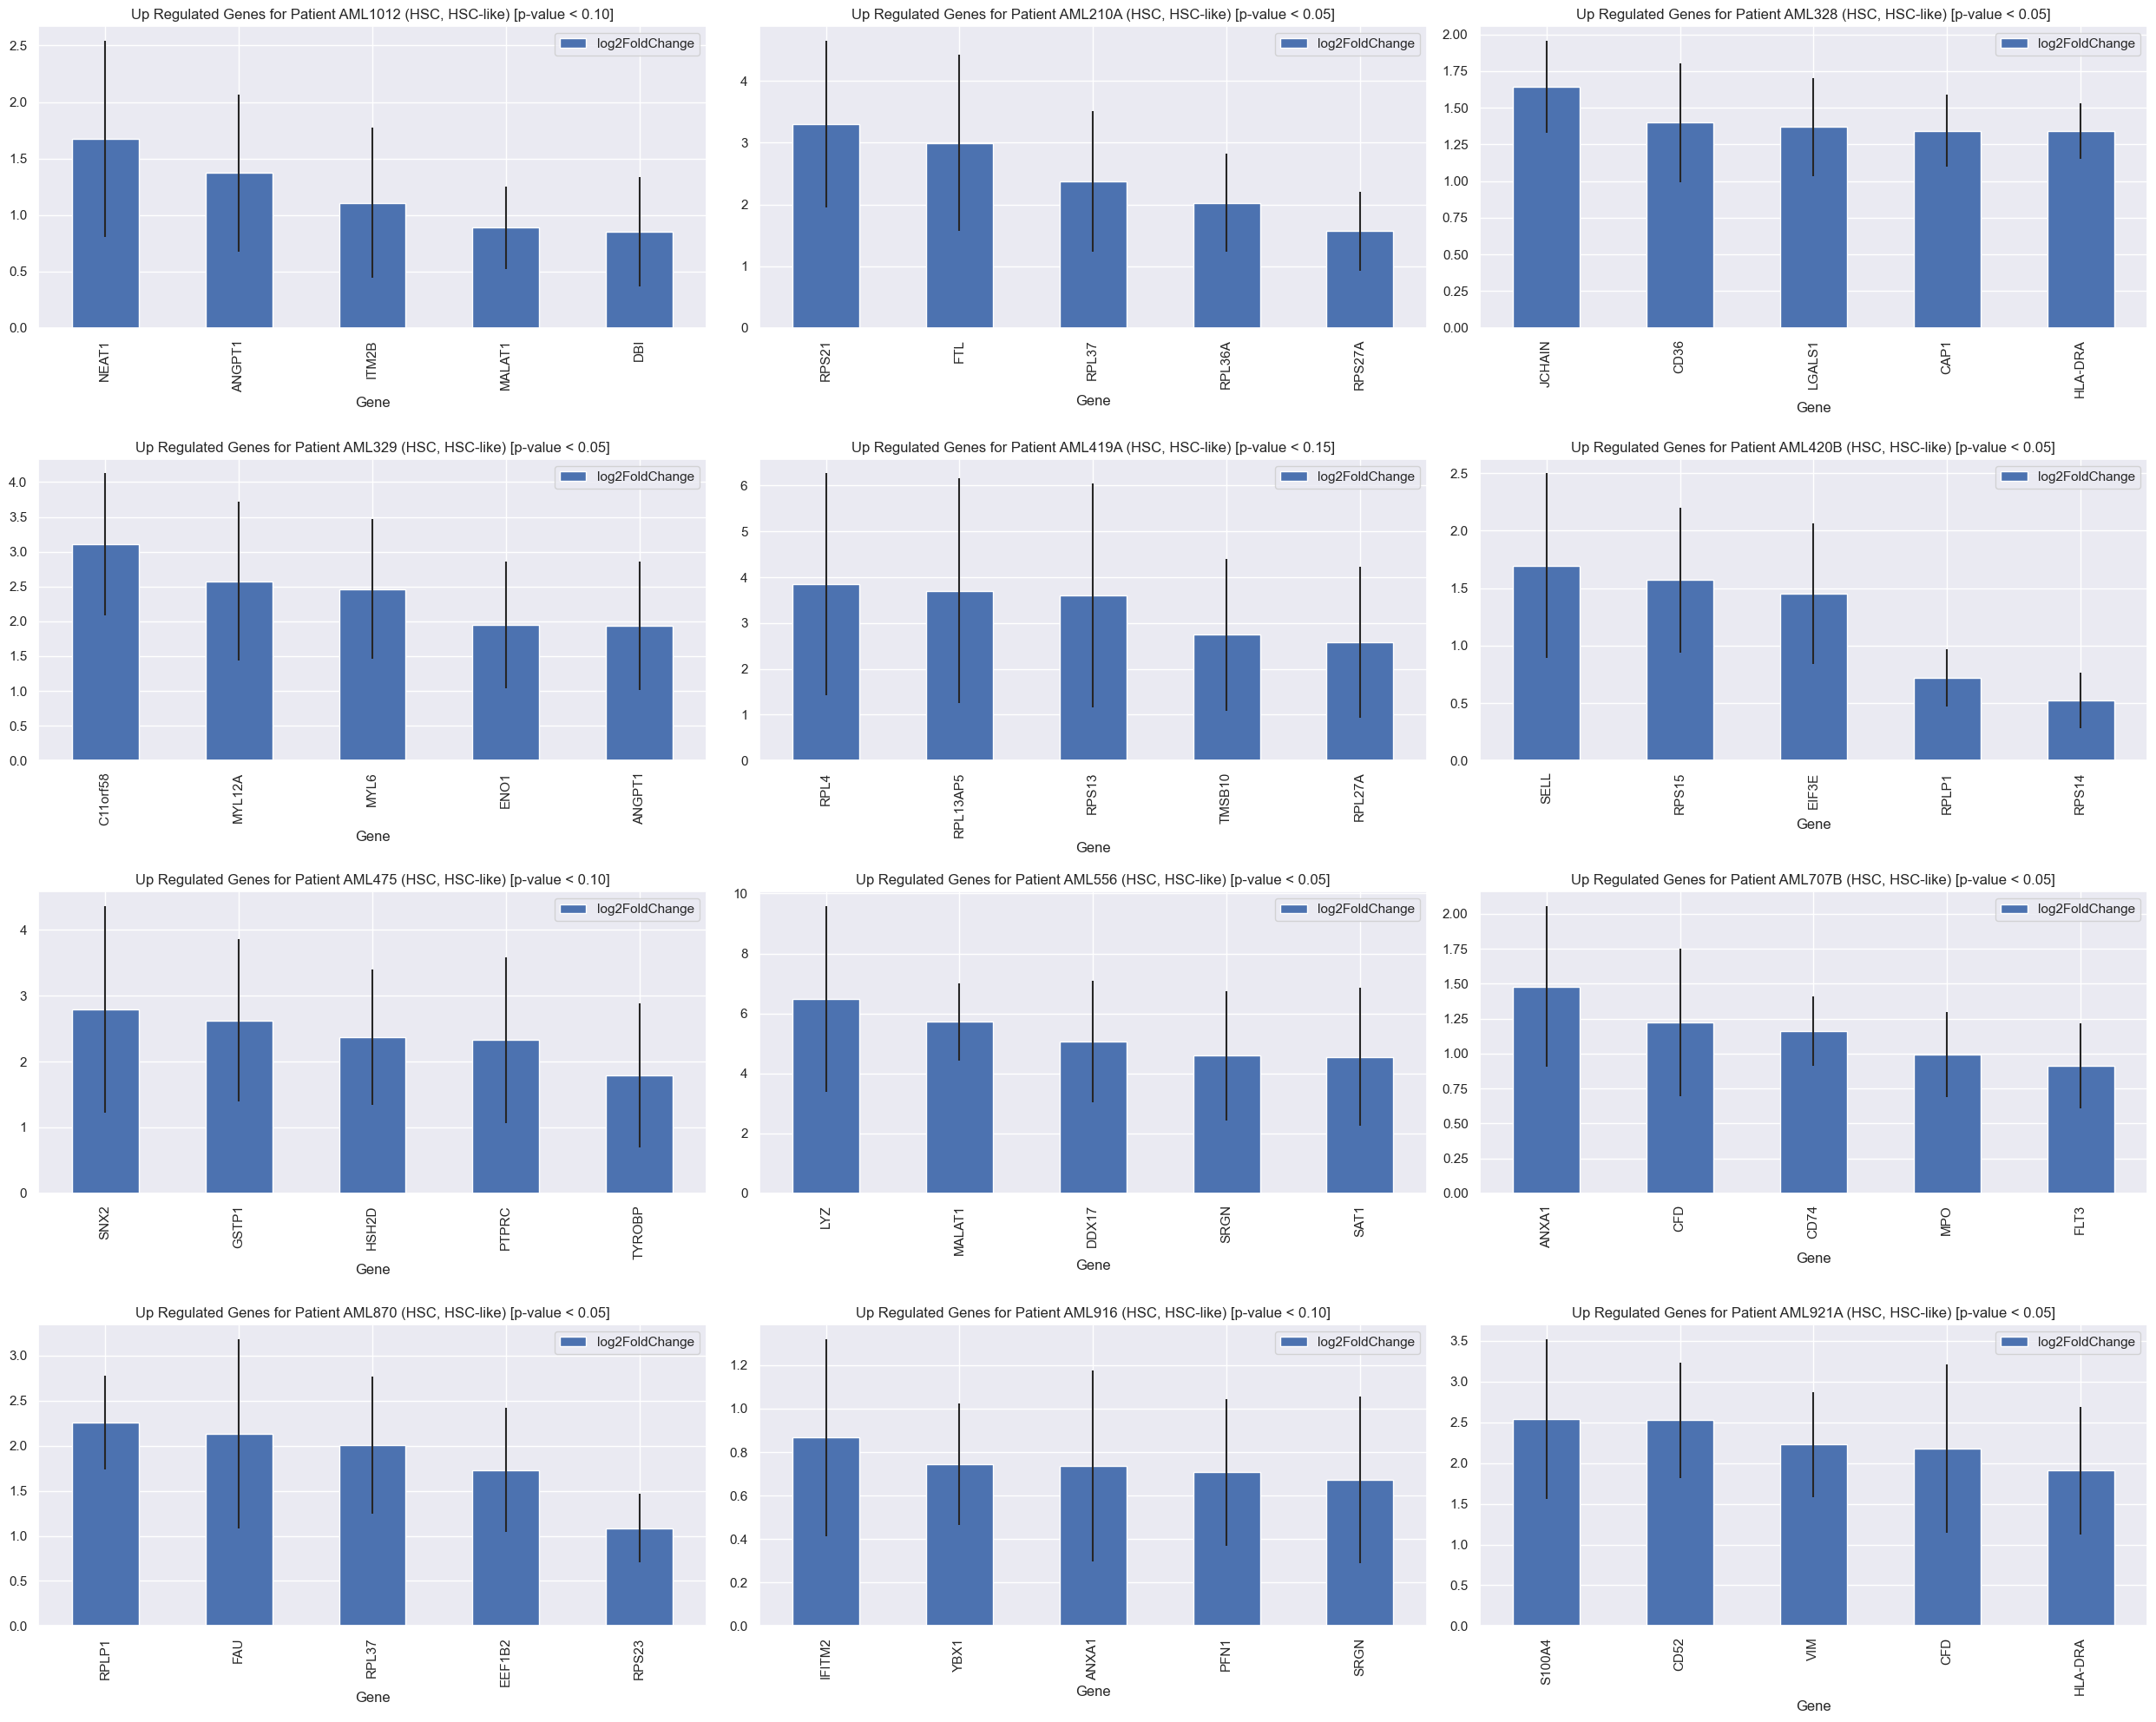

In [242]:
fig, axes = plt.subplots(4, 3, figsize=(25, 20))

for idx, patient in enumerate(results_patient):
    p_value_threshold = 0.05
    log2FoldChange_threshold = 0.05
    up_regulated = exract_down_up_regulated_genes(
        results_patient[patient],
        only_variably_expressed_genes=False,
        p_value_threshold=p_value_threshold,
        log2FoldChange_threshold=log2FoldChange_threshold,
    )["Up"]

    while len(up_regulated) < 4:
        p_value_threshold += 0.05
        up_regulated = exract_down_up_regulated_genes(
            results_patient[patient],
            only_variably_expressed_genes=False,
            p_value_threshold=p_value_threshold,
            log2FoldChange_threshold=log2FoldChange_threshold,
        )["Up"]

    up_regulated.head(5).plot.bar(
        y="log2FoldChange",
        yerr="lfcSE",
        title=f"Up Regulated Genes for Patient {patient} ({target_cell}, {target_cell}-like) [p-value < {p_value_threshold:.2f}]",
        ax=axes[idx // 3][idx % 3],
    )
    
    hsc_like = patient_cancerous_cells.filter(regex=f"^{patient}").sum(axis=1)
    hsc = patient_normal_cells.filter(regex=f"^{patient}").sum(axis=1)
    
    unique_proteins = hsc_like[(hsc_like > 0) & (hsc == 0)].index.intersection(up_regulated.index)
    print(f"Patient {patient} has {len(unique_proteins)} unique genes [p-value < {p_value_threshold:.2f} and log2FoldChange > {log2FoldChange_threshold}]")
    # if len(unique_proteins) > 0:
    #     print(unique_proteins)
    #     print(hsc[unique_proteins])

plt.tight_layout(h_pad=1.3)

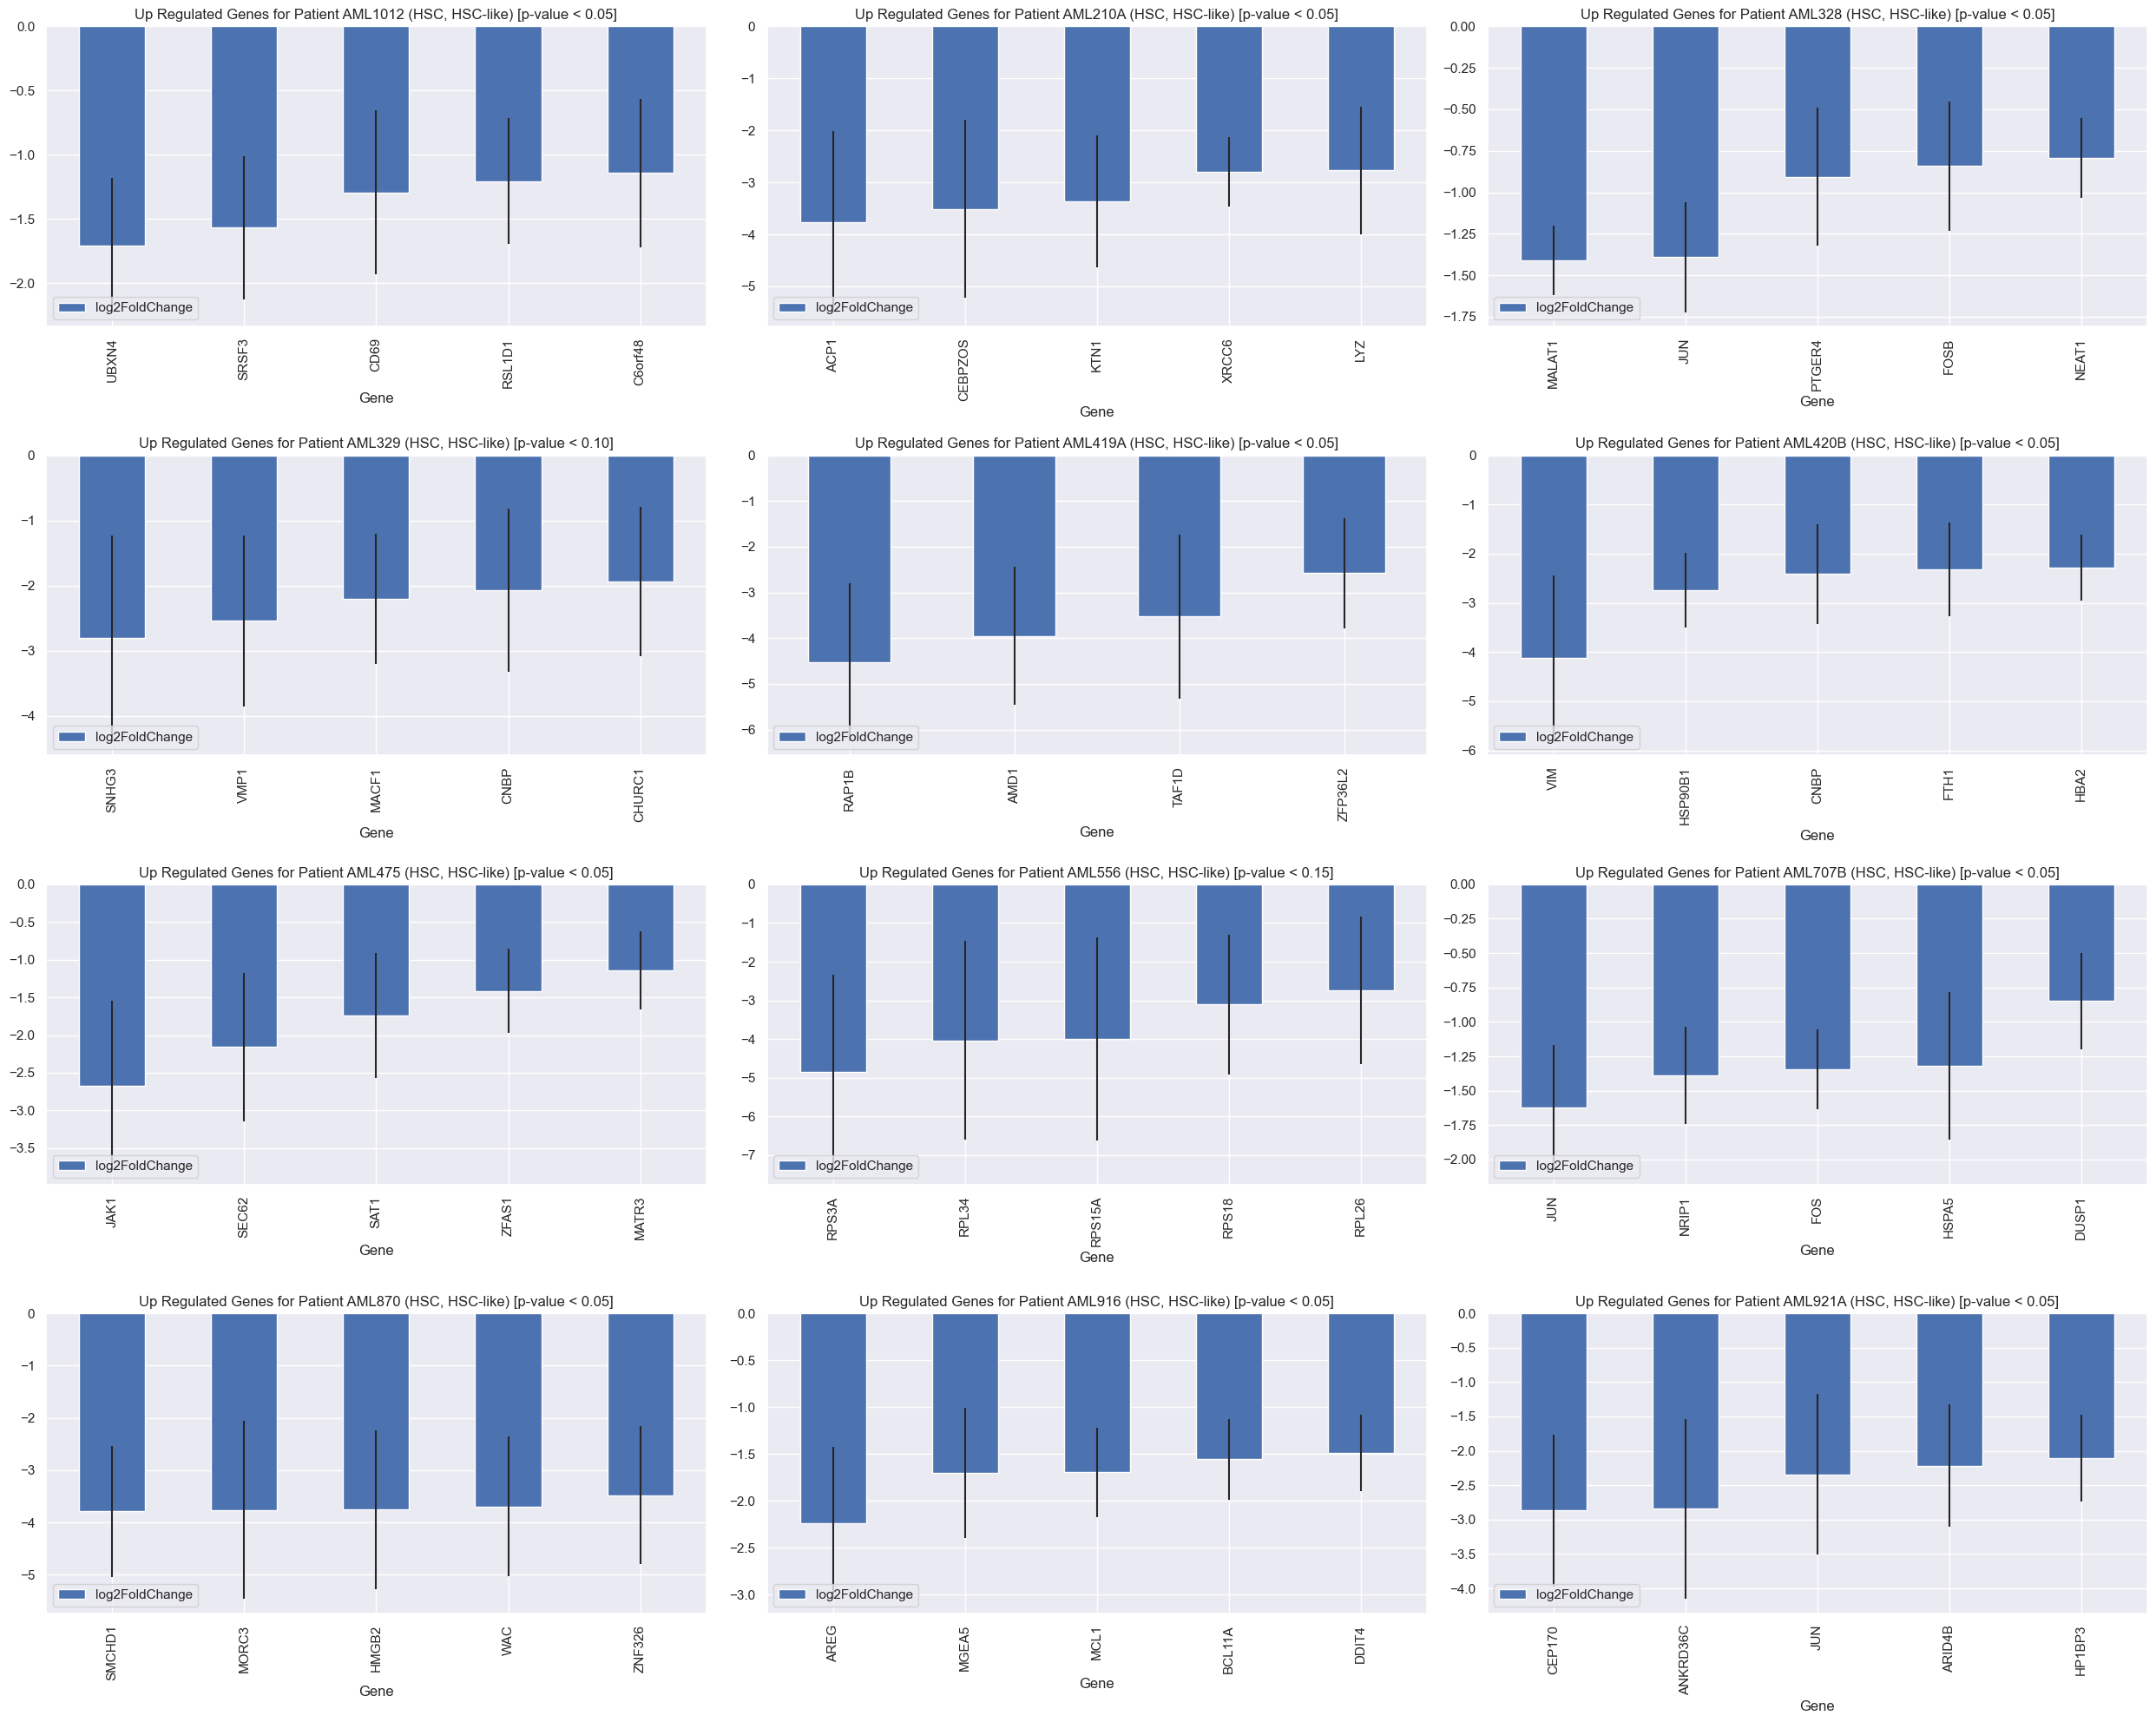

In [243]:
fig, axes = plt.subplots(4, 3, figsize=(25, 20))

for idx, patient in enumerate(results_patient):
    p_value_threshold = 0.05
    up_regulated = exract_down_up_regulated_genes(
        results_patient[patient], only_variably_expressed_genes=False, p_value_threshold=p_value_threshold,
    )["Down"]
    
    while len(up_regulated) < 4:
        p_value_threshold += 0.05
        up_regulated = exract_down_up_regulated_genes(
            results_patient[patient], only_variably_expressed_genes=False, p_value_threshold=p_value_threshold,
        )["Down"]
        
    up_regulated.head(5).plot.bar(
        y="log2FoldChange",
        yerr="lfcSE",
        title=f"Up Regulated Genes for Patient {patient} ({target_cell}, {target_cell}-like) [p-value < {p_value_threshold:.2f}]",
        ax=axes[idx // 3][idx % 3],
    )

plt.tight_layout(h_pad=1.3)

##### Patients:Normal Cells vs Patients:Cancerous Cells

In [244]:

data = prepare_data_for_DeseqDataSet(patient_cancerous_cells, patient_normal_cells)

inference = DefaultInference()
dds = DeseqDataSet(
    counts=data["count_data"],
    metadata=data["metadata"],
    design_factors="condition",
    refit_cooks=True,
    inference=inference,
)

dds.deseq2()

print(dds)

stat_res_un_un = DeseqStats(dds, inference=inference)

clear_output()

In [245]:
stat_res_un_un.summary()

Running Wald tests...
... done in 58.81 seconds.



Log2 fold change & Wald test p-value: condition 1.0 vs 0.0
          baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
Gene                                                                  
A1BG      0.105188       -0.190486  0.381884 -0.498806  0.617916   NaN
A1BG-AS1  0.017765       -0.313720  3.722831 -0.084269  0.932842   NaN
A1CF      0.000707       -0.310200  3.722872 -0.083323  0.933595   NaN
A2M       0.028634       -0.370990  1.246217 -0.297693  0.765938   NaN
A2M-AS1   0.015887       -0.275989  1.662367 -0.166022  0.868140   NaN
...            ...             ...       ...       ...       ...   ...
ZYG11A    0.005298       -0.323563  2.959889 -0.109316  0.912952   NaN
ZYG11B    0.089903       -0.205416  0.447978 -0.458541  0.646564   NaN
ZYX       0.143922       -0.099279  0.336725 -0.294838  0.768117   NaN
ZZEF1     0.112640       -0.271604  0.475470 -0.571232  0.567842   NaN
ZZZ3      0.143578       -0.200000  0.359933 -0.555659  0.578444   NaN

[27899 rows x 6 c

In [246]:
stat_res_un_un.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
A1BG,0.105188,-0.190486,0.381884,-0.498806,0.617916,NaN
A1BG-AS1,0.017765,-0.313720,3.722831,-0.084269,0.932842,NaN
A1CF,0.000707,-0.310200,3.722872,-0.083323,0.933595,NaN
A2M,0.028634,-0.370990,1.246217,-0.297693,0.765938,NaN
A2M-AS1,0.015887,-0.275989,1.662367,-0.166022,0.868140,NaN
...,...,...,...,...,...,...
ZYG11A,0.005298,-0.323563,2.959889,-0.109316,0.912952,NaN
ZYG11B,0.089903,-0.205416,0.447978,-0.458541,0.646564,NaN
ZYX,0.143922,-0.099279,0.336725,-0.294838,0.768117,NaN


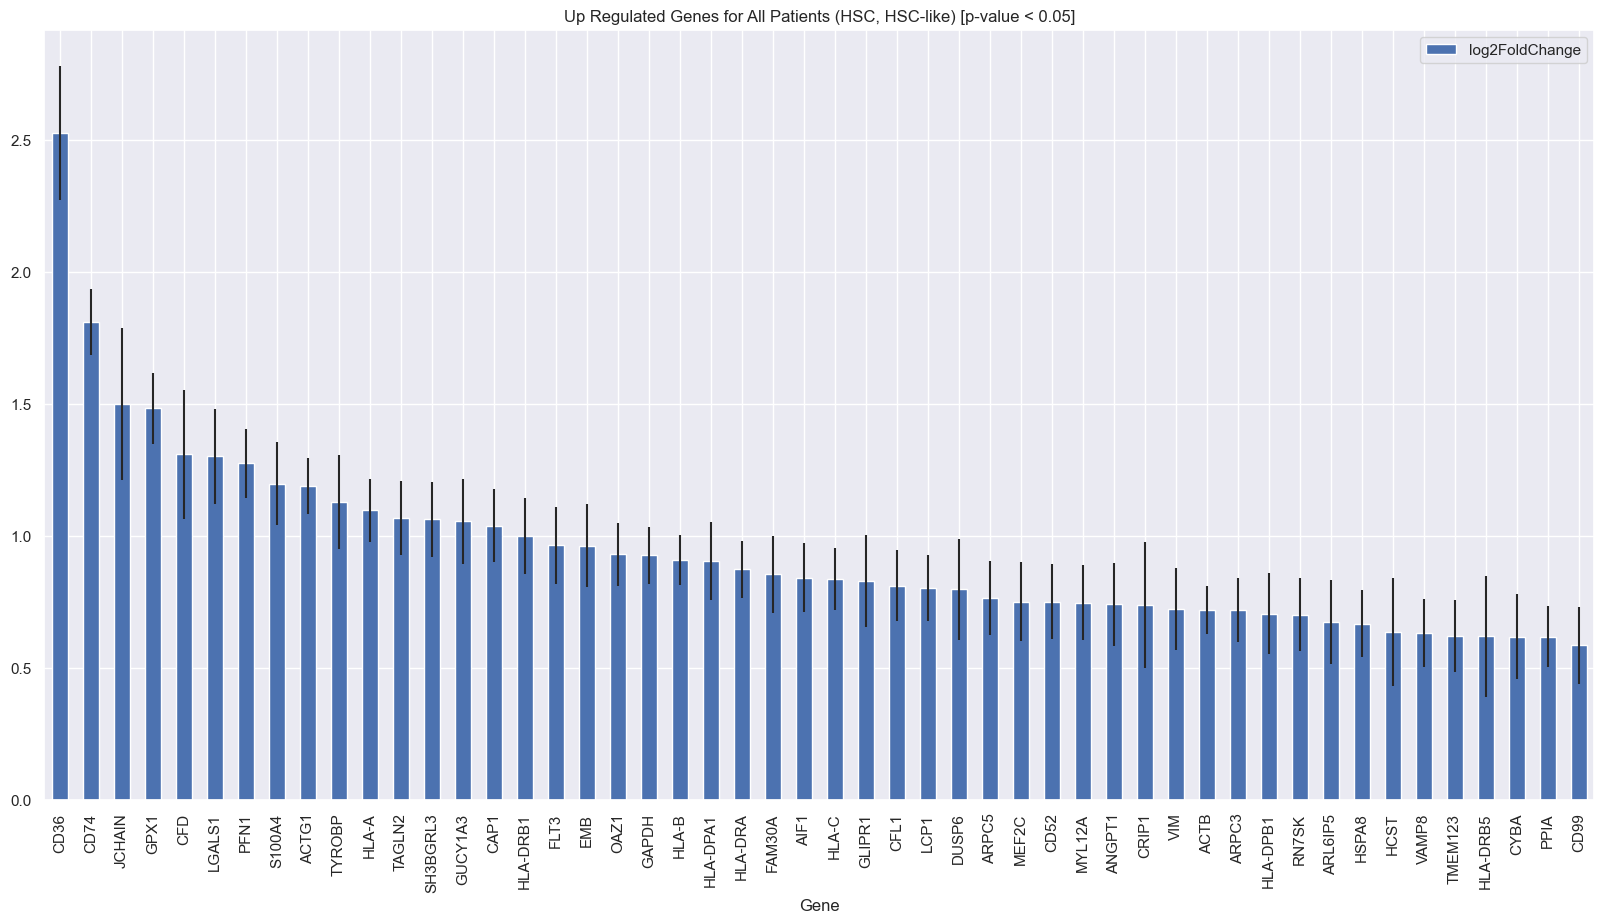

In [247]:
exract_down_up_regulated_genes(
    stat_res_un_un.results_df, only_variably_expressed_genes=False
)["Up"].head(50).plot.bar(y="log2FoldChange", yerr="lfcSE", title=f'Up Regulated Genes for All Patients ({target_cell}, {target_cell}-like) [p-value < 0.05]', figsize=(20, 10));

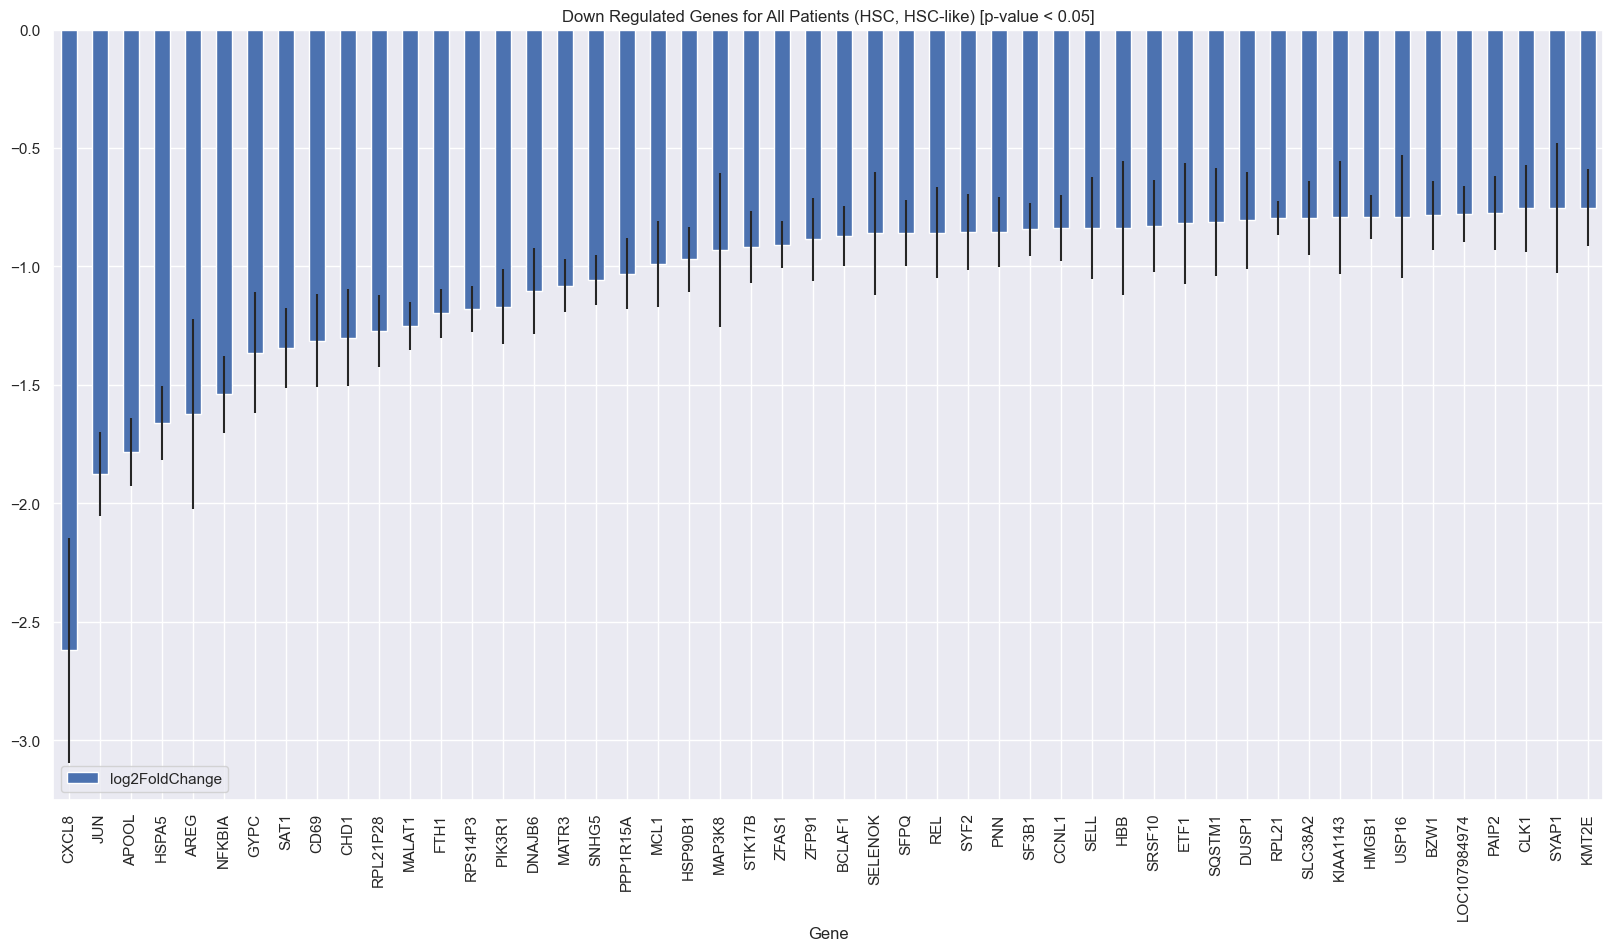

In [248]:
exract_down_up_regulated_genes(
    stat_res_un_un.results_df, only_variably_expressed_genes=False
)["Down"].head(50).plot.bar(y="log2FoldChange", yerr="lfcSE", title=f'Down Regulated Genes for All Patients ({target_cell}, {target_cell}-like) [p-value < 0.05]', figsize=(20, 10));

##### Impatients:Normal Cells vs Patients:Cancerous Cells

In [249]:

data = prepare_data_for_DeseqDataSet(patient_cancerous_cells, impatient_normal_cells)

inference = DefaultInference()
dds = DeseqDataSet(
    counts=data["count_data"],
    metadata=data["metadata"],
    design_factors="condition",
    refit_cooks=True,
    inference=inference,
)

dds.deseq2()

print(dds)

stat_res_un_h = DeseqStats(dds, inference=inference)

clear_output()

In [250]:
stat_res_un_h.summary()

Running Wald tests...
... done in 138.37 seconds.



Log2 fold change & Wald test p-value: condition 1.0 vs 0.0
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gene                                                                      
A1BG      0.108641        0.293770  0.260802  1.126413  0.259991  0.423990
A1BG-AS1  0.002288        0.228223  2.953006  0.077285  0.938397       NaN
A1CF      0.000581        0.226803  2.953019  0.076804  0.938780       NaN
A2M       0.011435        0.260900  1.178343  0.221413  0.824771       NaN
A2M-AS1   0.015342        0.250341  1.178316  0.212456  0.831751       NaN
...            ...             ...       ...       ...       ...       ...
ZYG11A    0.004526        0.230303  2.580569  0.089245  0.928887       NaN
ZYG11B    0.114525        0.208809  0.272064  0.767498  0.442785  0.581355
ZYX       0.122865        0.493534  0.271523  1.817655  0.069117  0.178001
ZZEF1     0.074864        0.334770  0.356034  0.940274  0.347077       NaN
ZZZ3      0.164946        0.105264  0.208

In [251]:
stat_res_un_h.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
A1BG,0.108641,0.293770,0.260802,1.126413,0.259991,0.423990
A1BG-AS1,0.002288,0.228223,2.953006,0.077285,0.938397,NaN
A1CF,0.000581,0.226803,2.953019,0.076804,0.938780,NaN
A2M,0.011435,0.260900,1.178343,0.221413,0.824771,NaN
A2M-AS1,0.015342,0.250341,1.178316,0.212456,0.831751,NaN
...,...,...,...,...,...,...
ZYG11A,0.004526,0.230303,2.580569,0.089245,0.928887,NaN
ZYG11B,0.114525,0.208809,0.272064,0.767498,0.442785,0.581355
ZYX,0.122865,0.493534,0.271523,1.817655,0.069117,0.178001


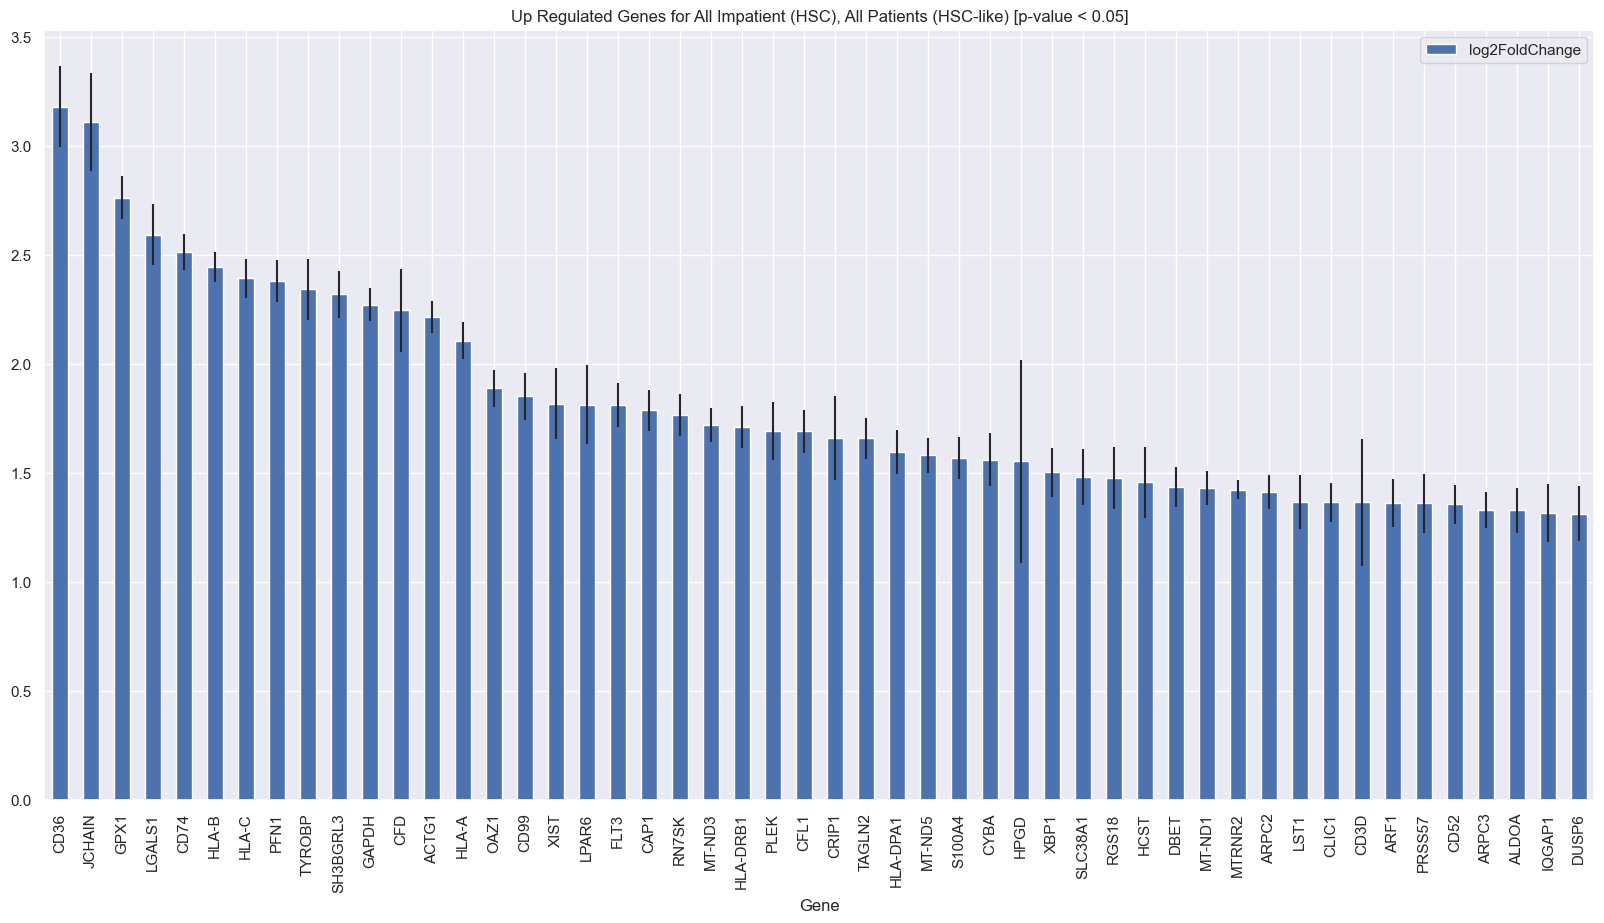

In [252]:
exract_down_up_regulated_genes(
    stat_res_un_h.results_df, only_variably_expressed_genes=False
)["Up"].head(50).plot.bar(y="log2FoldChange", yerr="lfcSE", title='Up Regulated Genes for All Impatient (HSC), All Patients (HSC-like) [p-value < 0.05]', figsize=(20, 10));

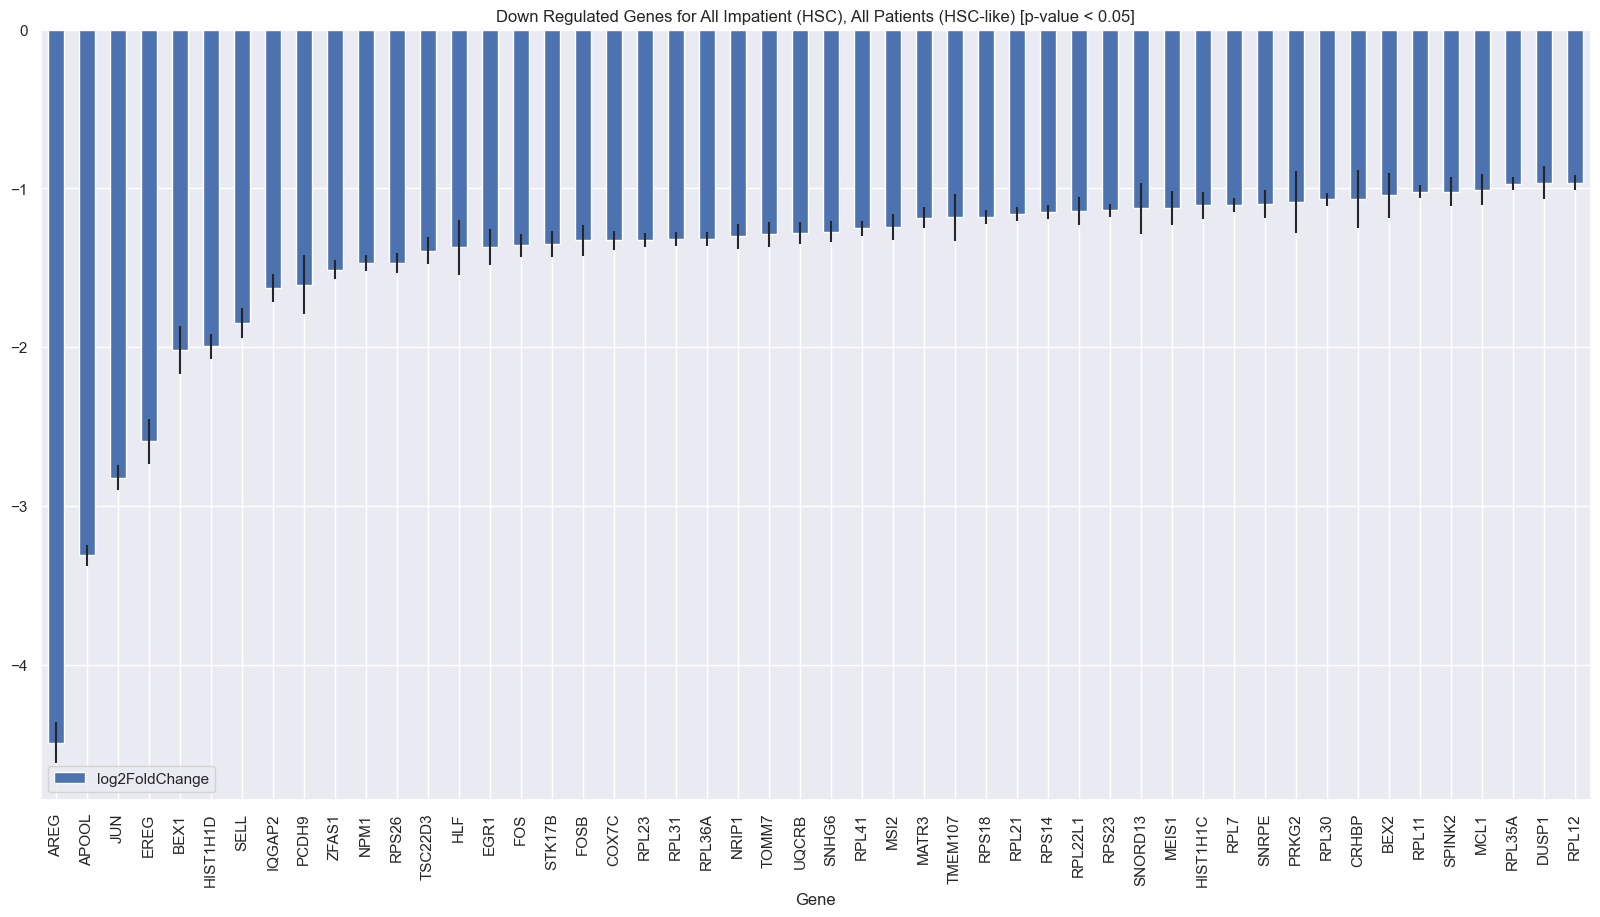

In [253]:
exract_down_up_regulated_genes(
    stat_res_un_h.results_df, only_variably_expressed_genes=False
)["Down"].head(50).plot.bar(y="log2FoldChange", yerr="lfcSE", title='Down Regulated Genes for All Impatient (HSC), All Patients (HSC-like) [p-value < 0.05]', figsize=(20, 10));

##### All:Normal Cells vs patients:Cancerous Cells

In [254]:

data = prepare_data_for_DeseqDataSet(patient_cancerous_cells, pd.concat([patient_normal_cells, impatient_normal_cells], axis=1))

inference = DefaultInference()
dds = DeseqDataSet(
    counts=data["count_data"],
    metadata=data["metadata"],
    design_factors="condition",
    refit_cooks=True,
    inference=inference,
)

dds.deseq2()

print(dds)

stat_res_un_a = DeseqStats(dds, inference=inference)

clear_output()

In [255]:
stat_res_un_a.summary()

Running Wald tests...
... done in 136.82 seconds.



Log2 fold change & Wald test p-value: condition 1.0 vs 0.0
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gene                                                                      
A1BG      0.103198        0.167689  0.247549  0.677399  0.498153       NaN
A1BG-AS1  0.012893        0.086531  2.561667  0.033779  0.973053       NaN
A1CF      0.000495        0.086549  2.893925  0.029907  0.976141       NaN
A2M       0.020652        0.096927  0.974541  0.099460  0.920773       NaN
A2M-AS1   0.013408        0.113112  1.149022  0.098442  0.921581       NaN
...            ...             ...       ...       ...       ...       ...
ZYG11A    0.004529        0.085899  2.122223  0.040476  0.967714       NaN
ZYG11B    0.106389        0.101641  0.262218  0.387622  0.698296       NaN
ZYX       0.115103        0.337091  0.256181  1.315829  0.188231       NaN
ZZEF1     0.092799        0.177995  0.329800  0.539706  0.589400       NaN
ZZZ3      0.156007        0.025255  0.198

In [256]:
stat_res_un_a.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
A1BG,0.103198,0.167689,0.247549,0.677399,0.498153,NaN
A1BG-AS1,0.012893,0.086531,2.561667,0.033779,0.973053,NaN
A1CF,0.000495,0.086549,2.893925,0.029907,0.976141,NaN
A2M,0.020652,0.096927,0.974541,0.099460,0.920773,NaN
A2M-AS1,0.013408,0.113112,1.149022,0.098442,0.921581,NaN
...,...,...,...,...,...,...
ZYG11A,0.004529,0.085899,2.122223,0.040476,0.967714,NaN
ZYG11B,0.106389,0.101641,0.262218,0.387622,0.698296,NaN
ZYX,0.115103,0.337091,0.256181,1.315829,0.188231,NaN


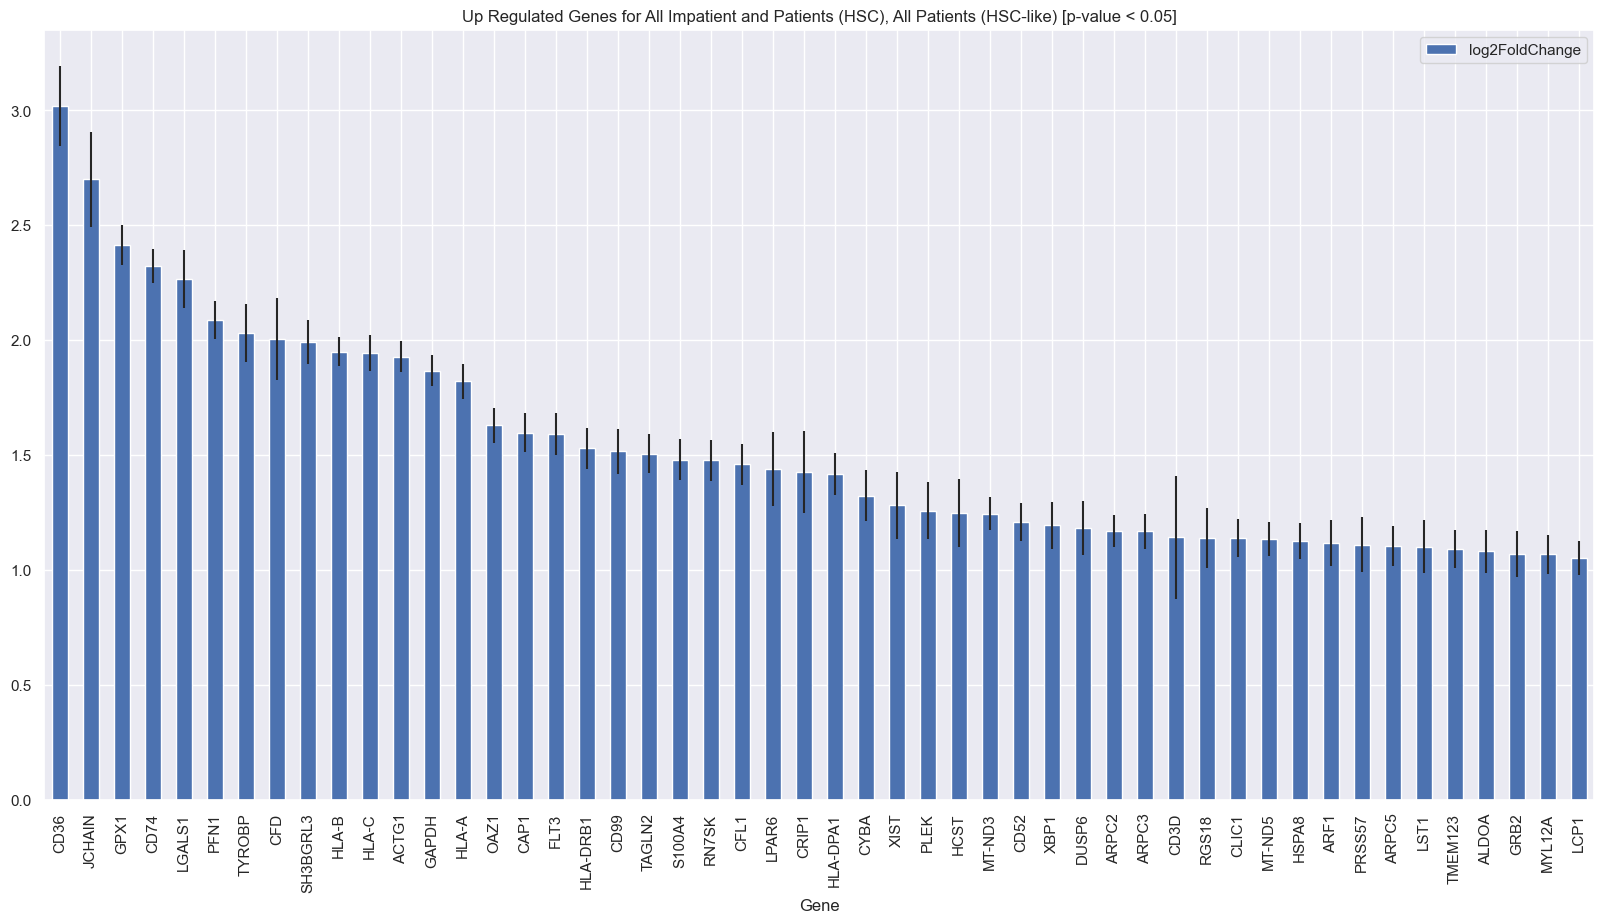

In [257]:
exract_down_up_regulated_genes(
    stat_res_un_a.results_df, only_variably_expressed_genes=False
)["Up"].head(50).plot.bar(y="log2FoldChange", yerr="lfcSE", title='Up Regulated Genes for All Impatient and Patients (HSC), All Patients (HSC-like) [p-value < 0.05]', figsize=(20, 10));

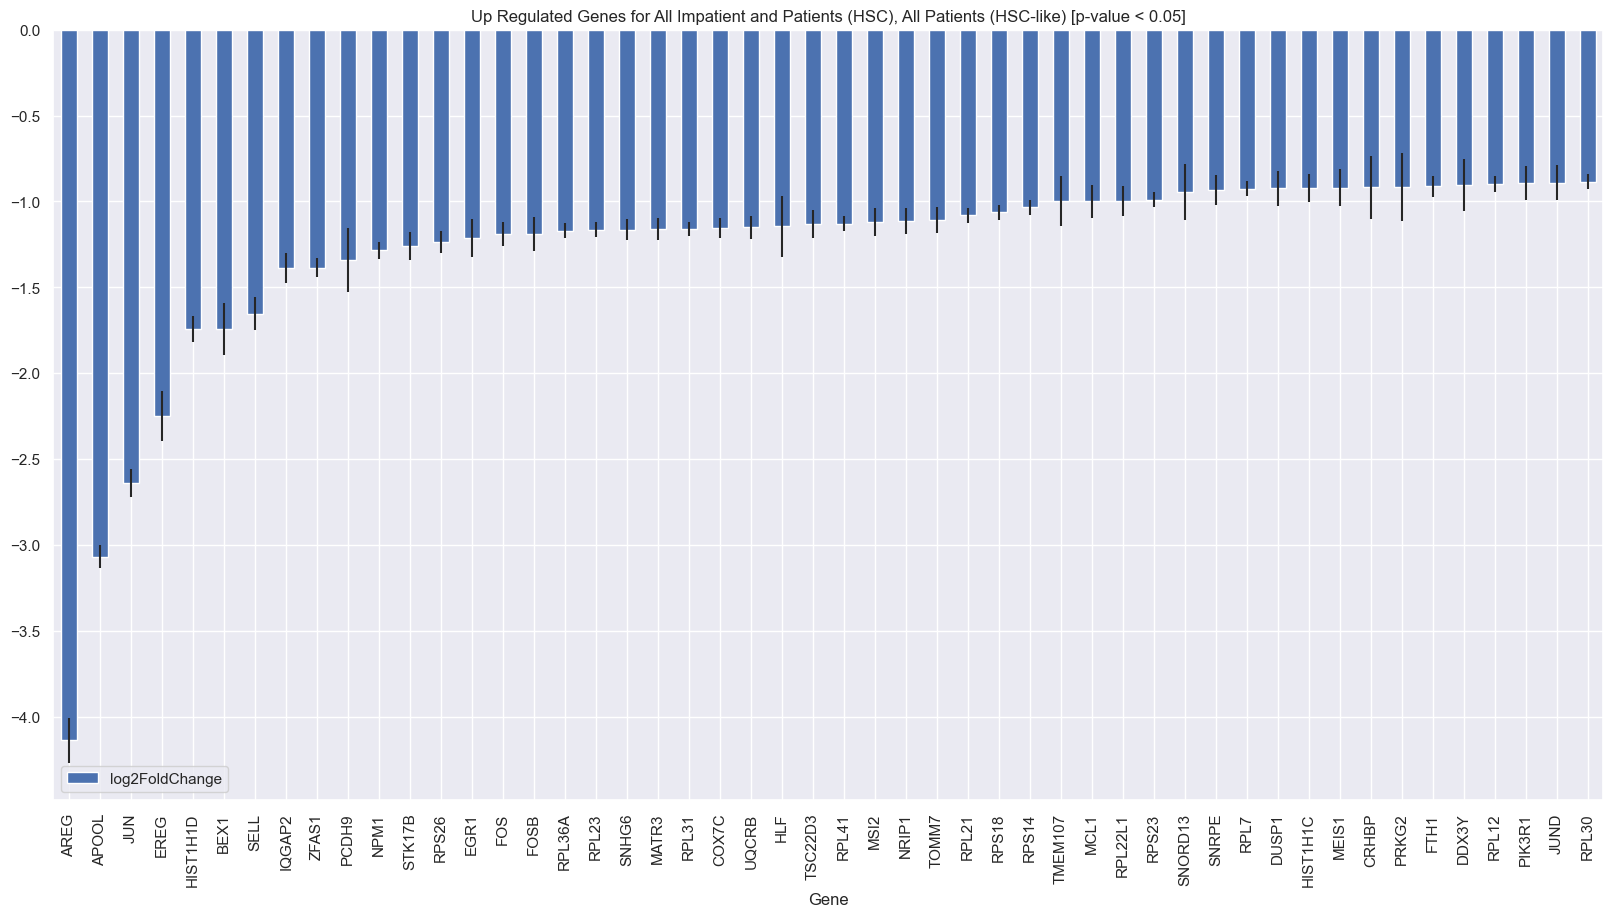

In [258]:
exract_down_up_regulated_genes(
    stat_res_un_a.results_df, only_variably_expressed_genes=False
)["Down"].head(50).plot.bar(y="log2FoldChange", yerr="lfcSE", title='Up Regulated Genes for All Impatient and Patients (HSC), All Patients (HSC-like) [p-value < 0.05]', figsize=(20, 10));